# Evaluation of Experiments

This notebook contains the evaluation of 6 different experiments. These include

[1] Baseline experiments of well-known AL strategies \
[2] Ablation Study concerning the Oracle Type and the number of batches that are selected per cycle. \
[3] Ablation Study of the query size for best performer of experiment [2] \
[4] Ablation Study of the Performance Estimation for best performer of experiment [2] \
[5] Ablation Study of the retraining process for best performer of experiment [2] \
[6] Running best Oracle model on all Image-Datasets [2] \
[7] Running best Oracle model on all Image-Datasets with a different backbone [2] \

Each Experiment will subsequently be introduced and results will be plottet.

In [1]:
# Some imports and general information

import mlflow
import numpy as np
import pandas as pd
import pylab as plt
from collections import defaultdict
import seaborn as sns
from IPython.display import display

# Command to sync the database
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_2.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/paul/perf_dal_2.db
# scp phahn@cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_2.db .

# Datasets
datasets = {
    'cifar10': {'qs':10, 'n':'CIFAR10'}, 
    'stl10':{'qs':10, 'n':'STL10'}, 
    'snacks':{'qs':20, 'n':'SNACKS'}, 
    'flowers102':{'qs':25, 'n':'Flowers102'}, 
    'dtd':{'qs':50, 'n':'DTD'}, 
    'food101':{'qs':100, 'n':'Food101'}, 
    'cifar100':{'qs':100, 'n':'CIFAR100'},
    'tiny_imagenet':{'qs':200, 'n': 'TinyImageNet'},
    'imagenet':{'qs':1000, 'n':'ImageNet'}
    }

# Query Strategies
query_strategies = {
    'alfamix':{'n':'AlfaMix', 'c':'red', 'ls':'-'},
    'badge':{'n':'BADGE', 'c':'blue', 'ls':'-'},
    'bait':{'n':'BAIT', 'c':'green', 'ls':'-'},
    'coreset':{'n':'CoreSet', 'c':'purple', 'ls':'-'},
    'dropquery':{'n':'DropQuery', 'c':'orange', 'ls':'-'},
    'margin':{'n':'Margin', 'c':'cyan', 'ls':'-'},
    'random':{'n':'Random', 'c':'black', 'ls':'-'},
    'typiclust':{'n':'Typiclust', 'c':'pink', 'ls':'-'},

    'lazy+vary oracle(11)':{'n':'Lazy+Var Oracle (11)', 'c':'red', 'ls':'--'},
    'lazy+vary oracle(55)':{'n':'Lazy+Var Oracle (55)', 'c':'red', 'ls':':'},
    'lazy+vary oracle(110)':{'n':'Lazy+Var Oracle (110)', 'c':'red', 'ls':'-.'},

    'lazy oracle(11)':{'n':'Lazy Oracle (11)', 'c':'green', 'ls':'--'},
    'lazy oracle(55)':{'n':'Lazy Oracle (55)', 'c':'green', 'ls':':'},
    'lazy oracle(110)':{'n':'Lazy Oracle (110)', 'c':'green', 'ls':'-.'},

    'naive oracle(11)':{'n':'Naive Oracle (11)', 'c':'blue', 'ls':'--'},
    'naive oracle(55)':{'n':'Naive Oracle (55)', 'c':'blue', 'ls':':'},
    'naive oracle(110)':{'n':'Naive Oracle (110)', 'c':'blue', 'ls':'-.'},

    'Lazy+Vary Oracle (acq_size = 5)':{'n':'acq_size = 5', 'c':'orange', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 10)':{'n':'acq_size = 10', 'c':'blue', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 20)':{'n':'acq_size = 20', 'c':'green', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 40)':{'n':'acq_size = 40', 'c':'red', 'ls':'--'},

    'Lazy+Vary Oracle (perf_est = cross_entropy)':{'n':'perf_est = cross_entropy', 'c':'red', 'ls':'--'},
    'Lazy+Vary Oracle (perf_est = zero_one)':{'n':'perf_est = zero_one', 'c':'blue', 'ls':'--'},
    'Lazy+Vary Oracle (perf_est = brier)':{'n':'perf_est = brier', 'c':'green', 'ls':'--'},

    'Lazy+Vary Oracle (train = train)':{'n':'train = train', 'c':'red', 'ls':'--'},
    'Lazy+Vary Oracle (train = update)':{'n':'train = update', 'c':'blue', 'ls':'--'},

    'lazy+vary+red oracle(11)':{'n':'Lazy+Var+Red Oracle (11)', 'c':'orange', 'ls':'--'},
    'lazy+vary+red oracle(55)':{'n':'Lazy+Var+Red Oracle (55)', 'c':'orange', 'ls':':'},
    'lazy+vary+red oracle(110)':{'n':'Lazy+Var+Red Oracle (110)', 'c':'orange', 'ls':'-.'},

    'lazy+vary+red oracle(5)':{'n':'Lazy+Var+Red Oracle (5)', 'c':'gray', 'ls':'--'},
    'lazy+vary+red oracle(25)':{'n':'Lazy+Var+Red Oracle (25)', 'c':'gray', 'ls':':'},
    'lazy+vary+red oracle(50)':{'n':'Lazy+Var+Red Oracle (50)', 'c':'gray', 'ls':'-.'},

    'lazy+vary+red(1) oracle(110)':{'n':'Lazy+Var+Red(1) Oracle (110)', 'c':'silver', 'ls':'-.'},
    'lazy+vary+red(2) oracle(110)':{'n':'Lazy+Var+Red(2) Oracle (110)', 'c':'red', 'ls':'-.'},
    'lazy+vary+red(3) oracle(110)':{'n':'Lazy+Var+Red(3) Oracle (110)', 'c':'green', 'ls':'-.'},
    'lazy+vary+red(4) oracle(110)':{'n':'Lazy+Var+Red(4) Oracle (110)', 'c':'blue', 'ls':'-.'},
    'lazy+vary+red(5) oracle(110)':{'n':'Lazy+Var+Red(5) Oracle (110)', 'c':'gray', 'ls':'-.'},
    'lazy+vary+red(6) oracle(110)':{'n':'Lazy+Var+Red(6) Oracle (110)', 'c':'yellow', 'ls':'-.'},
    'lazy+vary+red(7) oracle(110)':{'n':'Lazy+Var+Red(7) Oracle (110)', 'c':'purple', 'ls':'-.'},
    'lazy+vary+red(8) oracle(110)':{'n':'Lazy+Var+Red(8) Oracle (110)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary+red(9) oracle(110)':{'n':'Lazy+Var+Red(9) Oracle (110)', 'c':'pink', 'ls':'-.'},
    'lazy+vary+red(10) oracle(110)':{'n':'Lazy+Var+Red(10) Oracle (110)', 'c':'brown', 'ls':'-.'},
    'lazy+vary+red(11) oracle(110)':{'n':'Lazy+Var+Red(11) Oracle (110)', 'c':'black', 'ls':'-.'},

    'lazy+vary oracle(110) cross_entropy 10':{'n':'Cross Entropy (10)', 'c':'green', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 10':{'n':'Zero One (10)', 'c':'green', 'ls':'-'},
    'lazy+vary oracle(110) brier 10':{'n':'Brier (10)', 'c':'green', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 20':{'n':'Cross Entropy (20)', 'c':'blue', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 20':{'n':'Zero One (20)', 'c':'blue', 'ls':'-'},
    'lazy+vary oracle(110) brier 20':{'n':'Brier (20)', 'c':'blue', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 25':{'n':'Cross Entropy (25)', 'c':'pink', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 25':{'n':'Zero One (25)', 'c':'pink', 'ls':'-'},
    'lazy+vary oracle(110) brier 25':{'n':'Brier (25)', 'c':'pink', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 30':{'n':'Cross Entropy (30)', 'c':'orange', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 30':{'n':'Zero One (30)', 'c':'orange', 'ls':'-'},
    'lazy+vary oracle(110) brier 30':{'n':'Brier (30)', 'c':'orange', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 50':{'n':'Cross Entropy (50)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 50':{'n':'Zero One (50)', 'c':'cyan', 'ls':'-'},
    'lazy+vary oracle(110) brier 50':{'n':'Brier (50)', 'c':'cyan', 'ls':'--'},

    'Oracle':{'n':'Oracle', 'c':'black', 'ls':'-.'},

    "True - ['random', 'dropquery']":{'n':'DropQuery', 'c':'orange', 'ls':'-'}, 
    "False - ['random', 'dropquery']":{'n':'DropQuery', 'c':'orange', 'ls':'--'},
    "True - ['random', 'coreset']":{'n':'CoreSet', 'c':'purple', 'ls':'-'}, 
    "False - ['random', 'coreset']":{'n':'CoreSet', 'c':'purple', 'ls':'--'}, 
    "True - ['random', 'badge']":{'n':'BADGE', 'c':'blue', 'ls':'-'}, 
    "False - ['random', 'badge']":{'n':'BADGE', 'c':'blue', 'ls':'--'}, 
    "True - ['random', 'bait']":{'n':'BAIT', 'c':'green', 'ls':'-'}, 
    "False - ['random', 'bait']":{'n':'BAIT', 'c':'green', 'ls':'--'}, 
    "True - ['random', 'alfamix']":{'n':'AlfaMix', 'c':'red', 'ls':'-'}, 
    "False - ['random', 'alfamix']":{'n':'AlfaMix', 'c':'red', 'ls':'--'}, 
    "True - ['random', 'typiclust']":{'n':'Typiclust', 'c':'pink', 'ls':'-'}, 
    "False - ['random', 'typiclust']":{'n':'Typiclust', 'c':'pink', 'ls':'--'}, 
    "True - ['random', 'loss']":{'n':'TypiClass', 'c':'brown', 'ls':'-'},
    "False - ['random', 'loss']":{'n':'TypiClass', 'c':'brown', 'ls':'--'},
    "True - ['random', 'margin']":{'n':'Margin', 'c':'cyan', 'ls':'-'}, 
    "False - ['random', 'margin']":{'n':'Margin', 'c':'cyan', 'ls':'--'}, 
    "True - ['random', 'dropqueryclass']":{'n':'DropQueryClass', 'c':'yellow', 'ls':'-'},
    "False - ['random', 'dropqueryclass']":{'n':'DropQueryClass', 'c':'yellow', 'ls':'--'}
}

sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'marginsampling', 'typiclass', 'losssampling', 'dropqueryclass']
sampling_strategies_red =  ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'dropqueryclass']

# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

# Mlflow args
uri = 'sqlite:///perf_dal_2.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

def style_negative(v, props=''):
    return props if v.count('-') > 1 else None

def df_style(val):
    return "font-weight: bold"

In [3]:
# Plotting functions for a pairwise comparison in one dset, averaged over all dsets and a global comparison

def plot_global_pairwise_comparison(results, dsets, strategies):
    # Compute win rates
    win_rates = pd.DataFrame(index=strategies, columns=strategies)
    for strat1 in strategies:
        for strat2 in strategies:
            if strat1 == strat2:
                win_rates.loc[strat1, strat2] = 0.0
            else:
                accs1, accs2 = [], []
                for dset in dsets:
                    accs1.extend(results[dset][strat1])
                    accs2.extend(results[dset][strat2])
                means1 = np.mean(accs1, axis=1)
                means2 = np.mean(accs2, axis=1)
                comparisons = means1.round(4) > means2.round(4)
                wins = np.sum(comparisons) / min(means1.shape[0], means2.shape[0])
                win_rates.loc[strat1, strat2] = wins
    win_rates.index = [strat.capitalize() for strat in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    win_rates *= 100
    win_rates = win_rates.sort_index(axis=0)
    win_rates = win_rates.sort_index(axis=1)
    plt.figure(figsize=(6, 5))
    sns.heatmap(win_rates.astype(float).T, annot=True, fmt=".2f", cmap="coolwarm", center=50)
    plt.title(f"Global Pairwise Comparison")
    plt.ylabel("Challenged Strategy")
    plt.xlabel("Challenging Strategy")
    plt.tight_layout()
    plt.show() 

def plot_pairwise_comparison(results, dsets, strategies):
    # Compute win rates
    for dset in dsets:
        win_rates = pd.DataFrame(index=strategies, columns=strategies)
        for strat1 in strategies:
            for strat2 in strategies:
                if strat1 == strat2:
                    win_rates.loc[strat1, strat2] = 0.0
                else:
                    means1 = np.mean(results[dset][strat1], axis=1)
                    means2 = np.mean(results[dset][strat2], axis=1)
                    comparisons = means1.round(4) > means2.round(4)
                    wins = np.sum(comparisons) / min(means1.shape[0], means2.shape[0])
                    win_rates.loc[strat1, strat2] = wins
        win_rates.index = [strat.capitalize() for strat in win_rates.index]
        win_rates.columns = [strat.capitalize() for strat in win_rates.columns]
        # Plot the heatmap
        win_rates *= 100
        win_rates = win_rates.sort_index(axis=0)
        win_rates = win_rates.sort_index(axis=1)
        plt.figure(figsize=(6, 5))
        sns.heatmap(win_rates.astype(float).T, annot=True, fmt=".2f", cmap="coolwarm", center=50)
        plt.title(f"{dset.capitalize()}")
        plt.ylabel("Challenged Strategy")
        plt.xlabel("Challenging Strategy")
        plt.tight_layout()
        plt.show()

def plot_global_comparison(results, dsets, strategies):
    # Compute win rates
    win_rates = pd.DataFrame(index=dsets, columns=strategies)
    for dset in dsets:
        for strat1 in strategies:
            means1 = np.mean(results[dset][strat1], axis=1)
            comparisons = []
            for strat2 in strategies:
                if strat2 != strat1:
                    means2 = np.mean(results[dset][strat2], axis=1)
                    comparison = means1.round(4) > means2.round(4)
                    comparisons.append(comparison)
            comp = np.prod(comparisons, axis=0)
            wins = np.sum(comp) / means1.shape[0]
            win_rates.loc[dset, strat1] = wins

    win_rates.index = [dset.capitalize() for dset in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    win_rates *= 100
    win_rates = win_rates.sort_index(axis=0)
    win_rates = win_rates.sort_index(axis=1)

    plt.figure(figsize=(6, 5))
    plt.title(f"Highest AUC per Dataset (%)")
    sns.heatmap(win_rates.astype(float), annot=True, fmt=".2f", cmap="coolwarm", center=50)
    plt.ylabel("Dataset")
    plt.xlabel("Strategy")
    plt.tight_layout()
    plt.show()

## Experiment 1 - Baselines

The first experiment contains the runs including well-known DAL-strategies on a variety of different Datasets. These include:

Datasets = [CIFAR10, CIFAR100, STL10, Snacks, DTD, Food101, Flowers102, TinyImageNet, ImageNet]

DAL Query Strategiges = [AlfaMix, BADGE, BAIT, CoreSet, DropQuery, Margin, Random, Typiclust]

In [4]:
experiment_name = 'experiment_1'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_1 #####################################
Found 720 experiments for experiment_1 with expected 720 experiments.


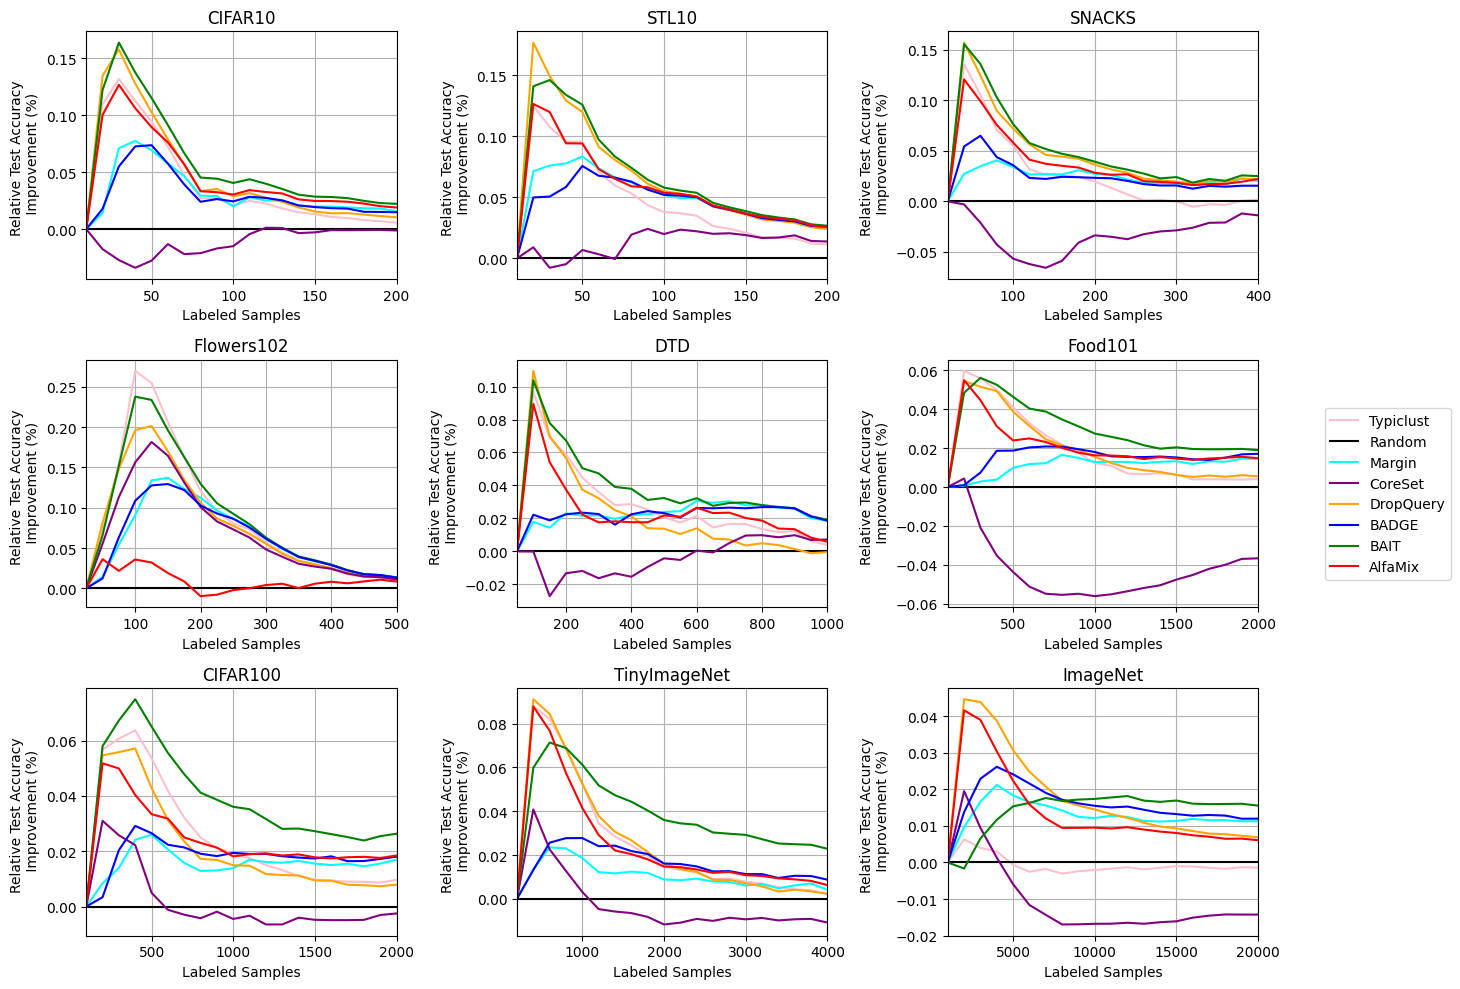

,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet
random,92.46+/-0.76,96.43+/-0.84,89.81+/-0.89,98.19+/-0.73,75.02+/-0.54,77.65+/-0.31,76.48+/-0.37,72.94+/-0.26,70.37+/-0.14
typiclust,0.55+/-0.3,1.06+/-0.29,-0.39+/-0.75,0.84+/-0.18,0.22+/-0.8,0.36+/-0.3,0.79+/-0.32,0.19+/-0.39,-0.11+/-0.18
margin,1.65+/-0.2,2.5+/-0.1,1.52+/-0.38,1.11+/-0.11,1.61+/-0.77,1.49+/-0.46,1.65+/-0.4,0.47+/-0.32,1.18+/-0.12
dropquery,1.06+/-0.33,2.26+/-0.09,1.92+/-0.6,0.98+/-0.14,-0.18+/-0.42,0.46+/-0.33,0.79+/-0.26,0.16+/-0.2,0.67+/-0.23
coreset,0.12+/-0.5,1.39+/-0.32,-1.26+/-0.79,0.9+/-0.11,0.46+/-0.59,-3.64+/-0.64,-0.31+/-0.55,-0.9+/-0.23,-1.31+/-0.2
bait,2.22+/-0.18,2.54+/-0.08,2.04+/-0.38,1.11+/-0.1,1.75+/-0.51,1.78+/-0.26,2.54+/-0.34,2.21+/-0.37,1.55+/-0.13
badge,1.45+/-0.27,2.48+/-0.1,1.39+/-0.61,1.1+/-0.08,1.63+/-0.51,1.61+/-0.43,1.74+/-0.27,0.94+/-0.25,1.26+/-0.16
alfamix,1.88+/-0.37,2.46+/-0.07,1.7+/-0.59,0.67+/-0.17,0.34+/-0.72,1.45+/-0.28,1.89+/-0.39,0.62+/-0.32,0.63+/-0.2


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet
random,0.833+/-0.016,0.882+/-0.011,0.827+/-0.01,0.812+/-0.014,0.658+/-0.007,0.675+/-0.005,0.667+/-0.005,0.63+/-0.003,0.619+/-0.002
typiclust,0.037+/-0.006,0.044+/-0.005,0.024+/-0.008,0.083+/-0.006,0.026+/-0.004,0.018+/-0.005,0.024+/-0.004,0.023+/-0.004,-0.001+/-0.002
margin,0.031+/-0.011,0.048+/-0.003,0.023+/-0.008,0.058+/-0.008,0.022+/-0.005,0.011+/-0.007,0.015+/-0.004,0.01+/-0.002,0.013+/-0.002
dropquery,0.045+/-0.006,0.063+/-0.004,0.043+/-0.005,0.073+/-0.004,0.02+/-0.004,0.018+/-0.003,0.02+/-0.002,0.024+/-0.002,0.017+/-0.002
coreset,-0.01+/-0.017,0.013+/-0.011,-0.031+/-0.016,0.065+/-0.008,-0.003+/-0.005,-0.041+/-0.007,0.001+/-0.005,-0.003+/-0.004,-0.01+/-0.002
bait,0.055+/-0.009,0.064+/-0.003,0.047+/-0.006,0.084+/-0.005,0.037+/-0.006,0.029+/-0.005,0.037+/-0.003,0.037+/-0.003,0.014+/-0.001
badge,0.029+/-0.008,0.044+/-0.006,0.023+/-0.005,0.058+/-0.01,0.022+/-0.008,0.015+/-0.006,0.018+/-0.004,0.016+/-0.002,0.015+/-0.002
alfamix,0.044+/-0.013,0.054+/-0.015,0.036+/-0.006,0.009+/-0.019,0.023+/-0.006,0.02+/-0.005,0.024+/-0.002,0.023+/-0.004,0.013+/-0.002


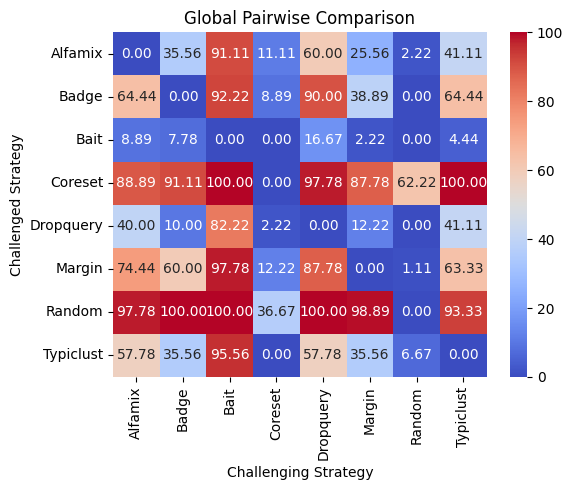

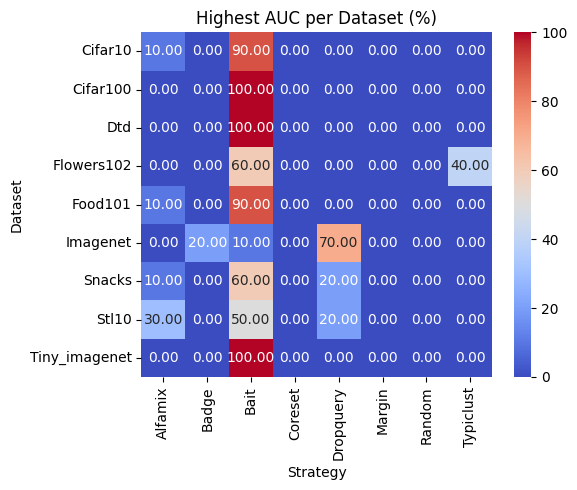

In [40]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(13, 10), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust']

for i, dset in enumerate(datasets):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['random'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['random'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
    final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i//3][i%3])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if qs in strategies:
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'random':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)
plot_global_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)

## Experiment 2 - Oracle Baselines

The second experiment investigates different variants of the oracle strategy and additionally tests them for different number of batches per cycle to investigate.

Oracle_Variants = [Naive, Lazy, Intelligent but Lazy]

Batch_Sizes = [11, 55, 110]

In [6]:
experiment_name = 'experiment_2'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3 * 3)) # n_dsets * n_seeds * n_oracles * n_batches

for run in runs_strategies:
    key = ('lazy' if 'typiclust' in run.data.params['al.optimal.strategies'] else 'naive') + ('+vary ' if run.data.params['al.optimal.vary_strat_subset_size'] == 'True' else ' ') + 'oracle' + '('+ run.data.params['al.optimal.num_batches'] +')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_2 #####################################
Found 180 experiments for experiment_2 with expected 180 experiments.


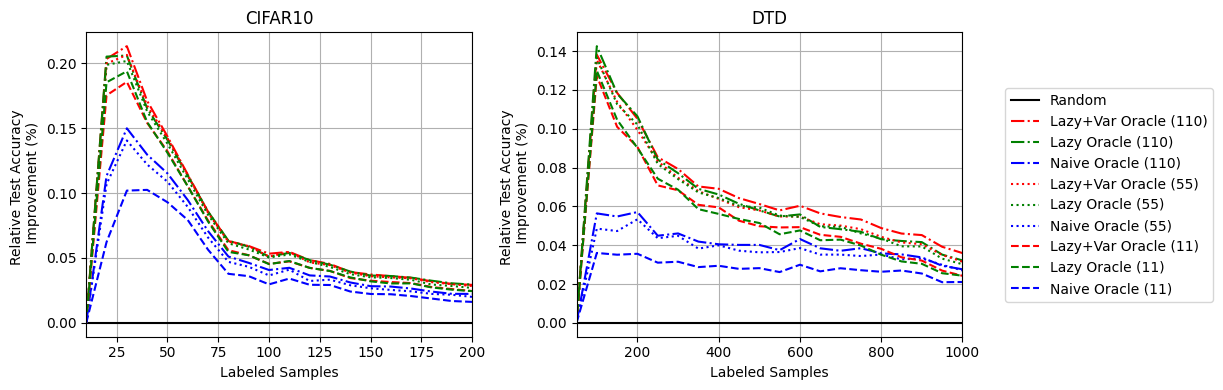

,cifar10,dtd
random,92.46+/-0.76,75.02+/-0.54
lazy+vary oracle(110),2.79+/-0.17,3.39+/-0.56
lazy oracle(110),2.9+/-0.13,3.01+/-0.35
naive oracle(110),2.17+/-0.19,2.63+/-0.48
lazy+vary oracle(55),2.8+/-0.19,3.11+/-0.55
lazy oracle(55),2.71+/-0.18,2.67+/-0.69
naive oracle(55),1.97+/-0.25,2.53+/-0.37
lazy+vary oracle(11),2.41+/-0.13,2.12+/-0.5
lazy oracle(11),2.44+/-0.2,2.14+/-0.37
naive oracle(11),1.62+/-0.3,1.88+/-0.28


,cifar10,dtd
random,0.833+/-0.016,0.658+/-0.007
lazy+vary oracle(110),0.072+/-0.007,0.063+/-0.004
lazy oracle(110),0.072+/-0.006,0.06+/-0.004
naive oracle(110),0.054+/-0.007,0.038+/-0.005
lazy+vary oracle(55),0.071+/-0.007,0.059+/-0.003
lazy oracle(55),0.069+/-0.006,0.058+/-0.005
naive oracle(55),0.05+/-0.008,0.036+/-0.003
lazy+vary oracle(11),0.064+/-0.007,0.052+/-0.004
lazy oracle(11),0.065+/-0.007,0.051+/-0.003
naive oracle(11),0.04+/-0.009,0.027+/-0.004


In [7]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}

for i, dset in enumerate(['cifar10', 'dtd']):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['random'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['random'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
    final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if ('oracle' in qs and ('naive' in qs or 'lazy+vary' in qs or 'lazy' in qs)) or qs == 'random':
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'random':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.225, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

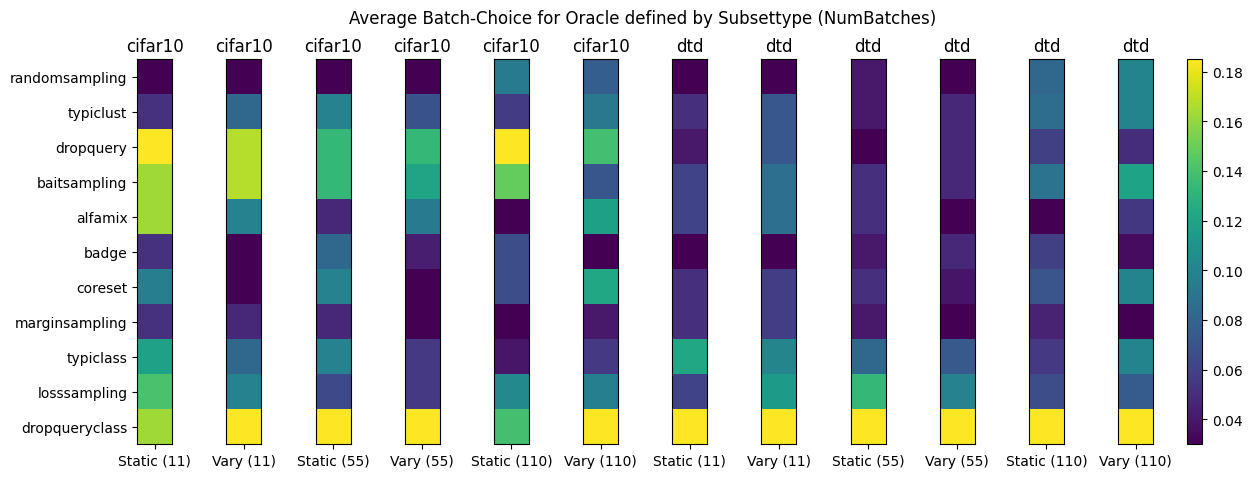

In [8]:
cmap = 'viridis'
fig_strats = ['lazy oracle(11)', 'lazy+vary oracle(11)', 'lazy oracle(55)', 'lazy+vary oracle(55)', 'lazy oracle(110)', 'lazy+vary oracle(110)']
fig_dsets = ['cifar10', 'dtd']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(14, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Oracle defined by Subsettype (NumBatches)")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[("Vary" if "vary" in strat else "Static") + " ("+strat.split('(')[1][:-1]+")"])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

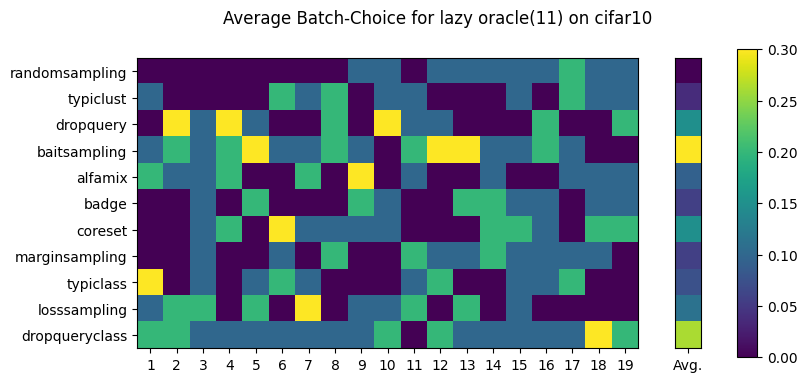

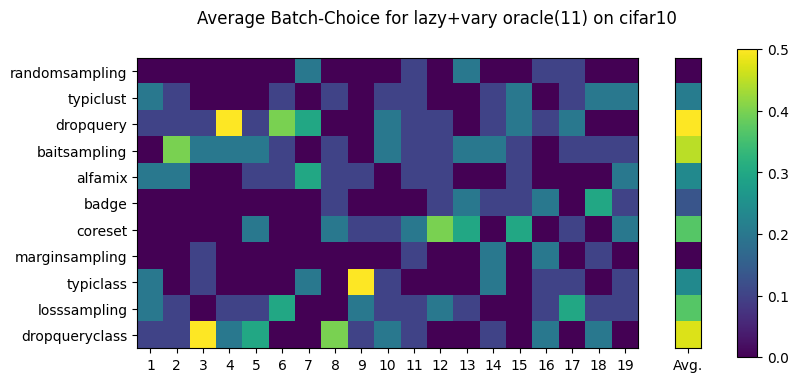

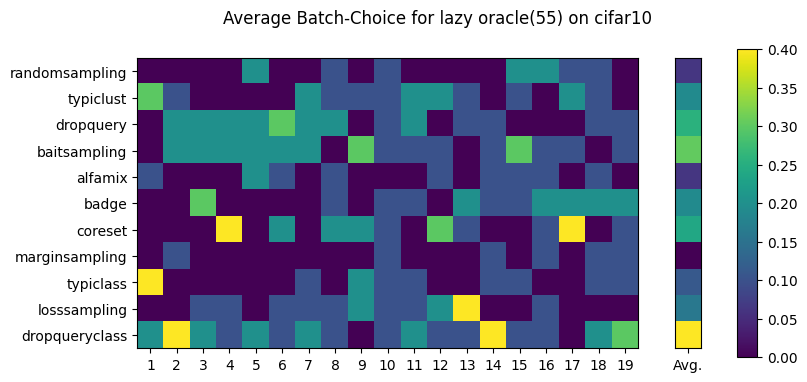

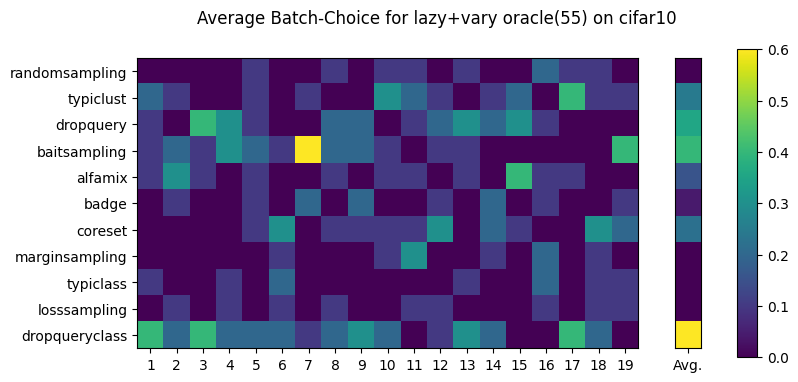

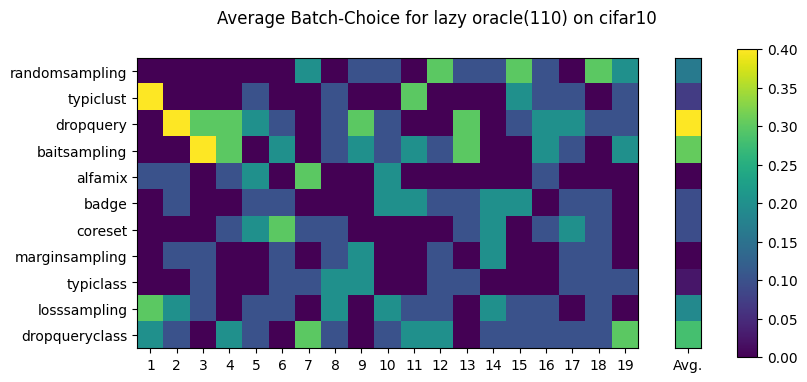

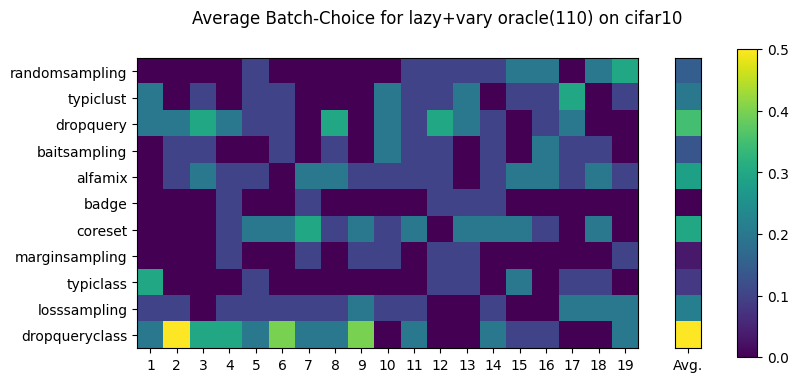

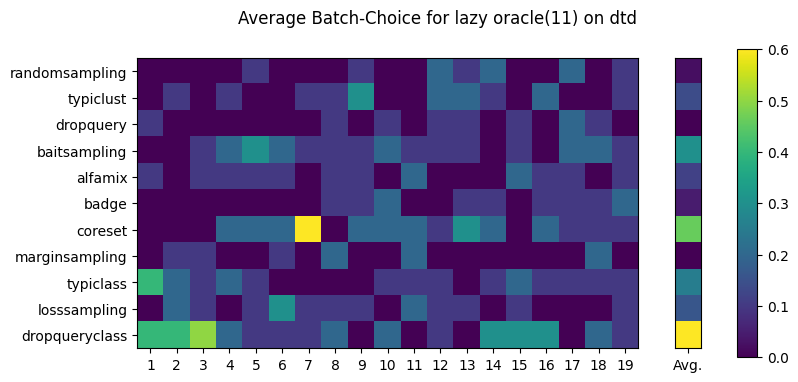

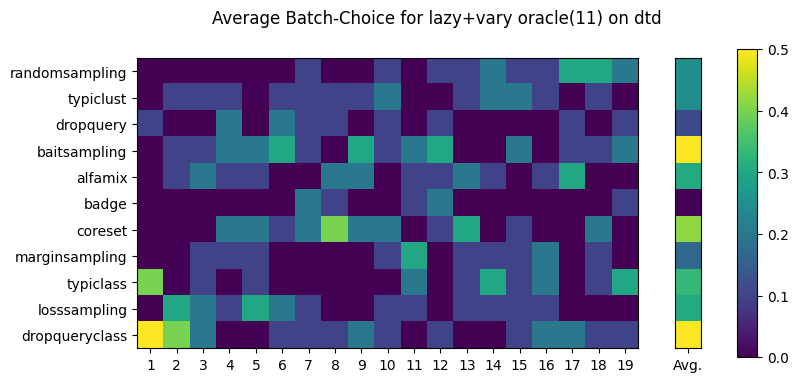

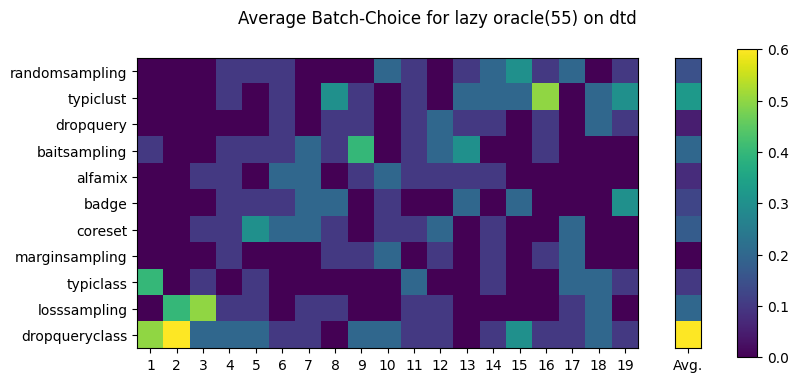

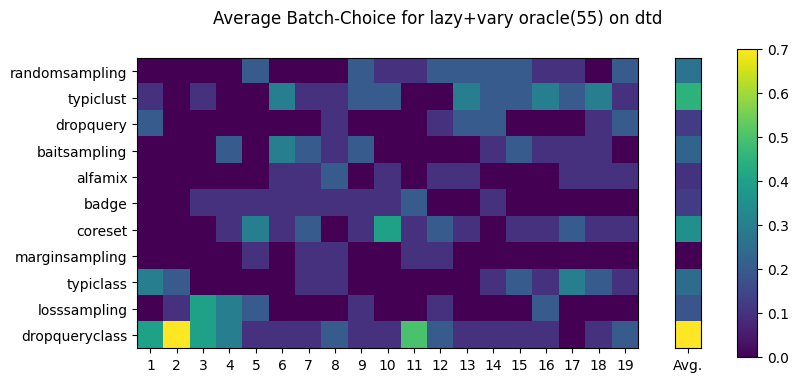

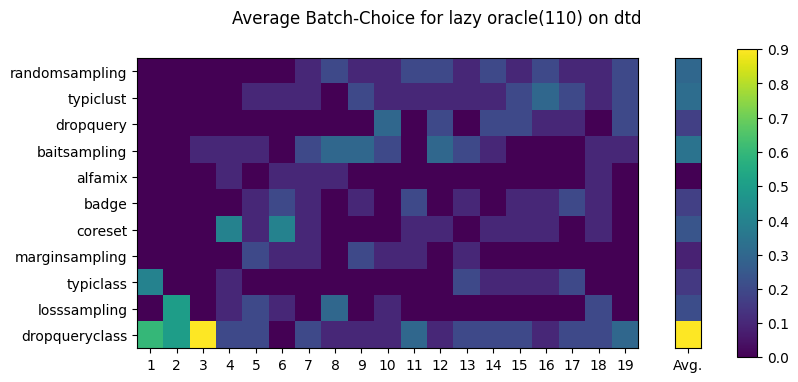

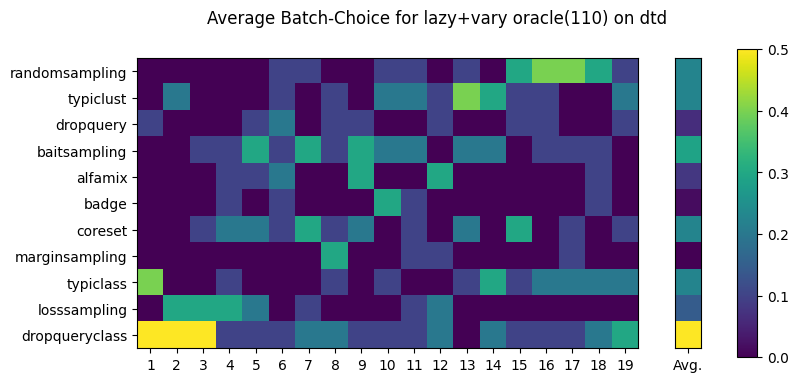

In [9]:
cmap = 'viridis'
for dset in ['cifar10', 'dtd']:
    for strat in ['lazy oracle(11)', 'lazy+vary oracle(11)', 'lazy oracle(55)', 'lazy+vary oracle(55)', 'lazy oracle(110)', 'lazy+vary oracle(110)']:
        fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(8, 4), width_ratios=[19., 1., .75])
        fig.suptitle(f"Average Batch-Choice for {strat} on {dset}")

        query_size = datasets[dset]['qs']
        n_queries = 20

        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img_avg = np.mean(image, axis=1)[:,1:]
        img_avg_avg = np.mean(img_avg, axis=-1)

        c1 = ax[0].imshow(img_avg)
        ax[0].set_xticks(ticks=range(0,19), labels=range(1, 20))
        ax[0].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)

        ax[1].imshow(img_avg_avg.reshape(-1, 1))
        ax[1].set_xticks(ticks=[0], labels=["Avg."])
        ax[1].set_yticks(ticks=[], labels=[])

        fig.colorbar(c1, cax=ax[-1])
        plt.show()

## Experiment 3 - How does the query size impact the oracle?

This experiment demonstrates the change in performance when increasing the acq_size while keeping the total number of acquisitions over the experiment constant. 

We only use the strategy lazy+vary oracle(110) as it is the strongest performer.

Num_Acqs = [10, 20, 40]

Datasets = [CIFAR10, STL10]

In [10]:
experiment_name = 'experiment_3'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 4)) # n_dsets * n_seeds * n_acq_sizes

for run in runs_strategies:
    key = f'Lazy+Vary Oracle (acq_size = '+run.data.params['al.acq_size']+')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_3 #####################################
Found 60 experiments for experiment_3 with expected 80 experiments.
Issue with Lazy+Vary Oracle (acq_size = 5) cifar10 Seed_7


In [11]:
auc_values_rel = {}
final_acc_rel = {}

for i, dset in enumerate(['cifar10', 'stl10']):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['random'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['random'] = str(rand_auc_mean.round(2)) + '+/-' + str(rand_auc_std.round(2))
    final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if 'acq_size' in qs or qs == 'random':
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'random':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(2)) + '+/-' + str(aucs_std.round(2))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

,cifar10,stl10
random,92.46+/-0.76,96.43+/-0.84
Lazy+Vary Oracle (acq_size = 20),2.65+/-0.21,2.59+/-0.07
Lazy+Vary Oracle (acq_size = 5),3.02+/-0.14,2.62+/-0.09
Lazy+Vary Oracle (acq_size = 10),2.79+/-0.17,2.62+/-0.09


,cifar10,stl10
random,0.83+/-0.02,0.88+/-0.01
Lazy+Vary Oracle (acq_size = 20),0.05+/-0.01,0.05+/-0.0
Lazy+Vary Oracle (acq_size = 5),0.08+/-0.0,0.08+/-0.0
Lazy+Vary Oracle (acq_size = 10),0.07+/-0.01,0.07+/-0.0


## Experiment 4 - How does the performance estimation impact the oracle?

In this experiment, we investigate the influence of the performance metric used for evaluating the different batches.

Perf_Est = [Cross Entropy, 0/1 Loss, Brier Score]

In [12]:
experiment_name = 'experiment_4'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_loss_fn

for run in runs_strategies:
    key = f'Lazy+Vary Oracle (perf_est = '+run.data.params['al.optimal.loss']+')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_4 #####################################
Found 60 experiments for experiment_4 with expected 60 experiments.


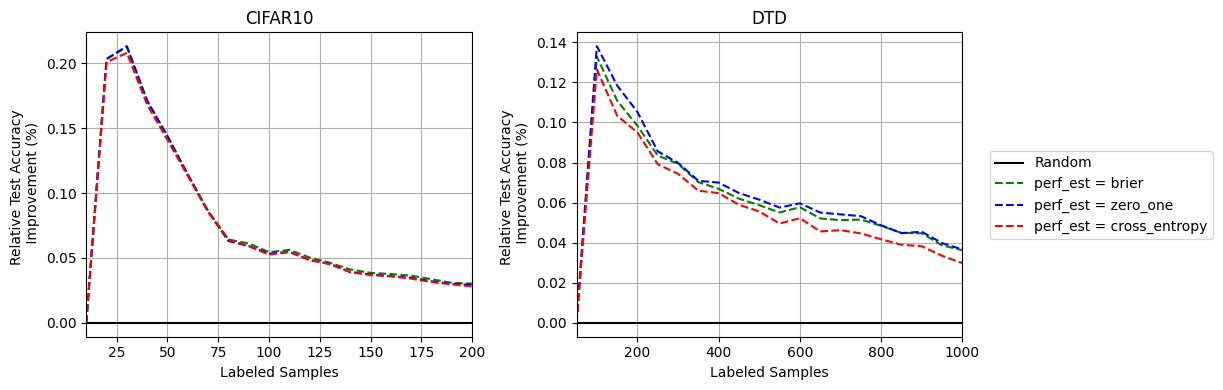

,cifar10,dtd
random,92.46+/-0.76,75.02+/-0.54
Lazy+Vary Oracle (perf_est = brier),2.98+/-0.16,3.36+/-0.48
Lazy+Vary Oracle (perf_est = zero_one),2.79+/-0.17,3.4+/-0.6
Lazy+Vary Oracle (perf_est = cross_entropy),2.81+/-0.12,2.76+/-0.57


,cifar10,dtd
random,0.833+/-0.016,0.658+/-0.007
Lazy+Vary Oracle (perf_est = brier),0.073+/-0.007,0.061+/-0.003
Lazy+Vary Oracle (perf_est = zero_one),0.072+/-0.007,0.063+/-0.005
Lazy+Vary Oracle (perf_est = cross_entropy),0.072+/-0.006,0.056+/-0.004


In [13]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}

for i, dset in enumerate(['cifar10', 'dtd']):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['random'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['random'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
    final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if ('perf' in qs) or qs == 'random':
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'random':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.225, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

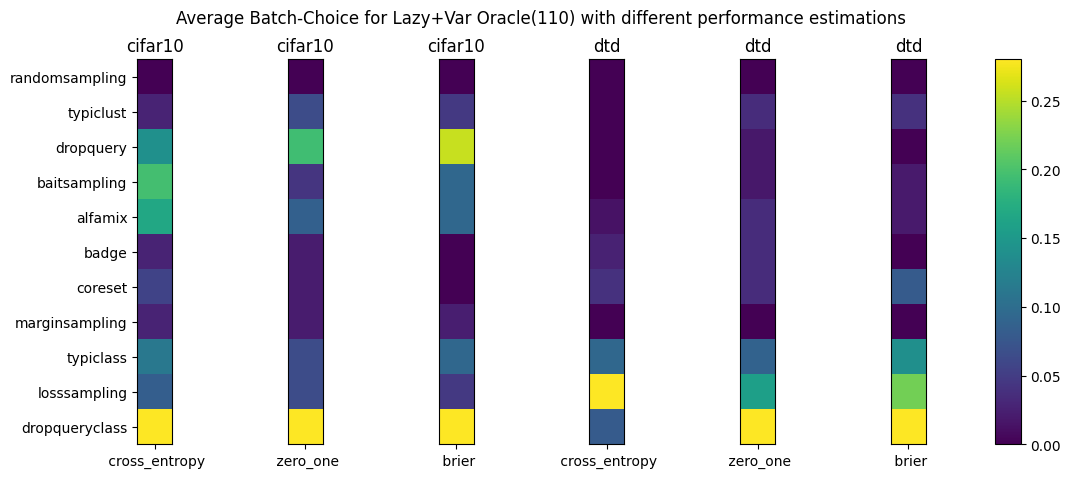

In [14]:
cmap = 'viridis'
fig_strats = ['Lazy+Vary Oracle (perf_est = cross_entropy)', 'Lazy+Vary Oracle (perf_est = zero_one)', 'Lazy+Vary Oracle (perf_est = brier)']
fig_dsets = ['cifar10', 'dtd']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(12, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Lazy+Var Oracle(110) with different performance estimations")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[strat.split('=')[1][:-1]])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

## Experiment 5 - How does the retraining process impact the oracle?

This experiment investigates wether using bayesian updates instead of retraining the model from scratch can serve as a good performance estimator, making the oracle more efficient.

In [15]:
experiment_name = 'experiment_5'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 5 * 3)) # n_dsets * n_seeds * n_gammas * n_loss_fn

for run in runs_strategies:
    loss_fn = run.data.params['al.optimal.loss']
    update_gamma = run.data.params['al.optimal.update_gamma']

    key = f'lazy+vary oracle(110) ' + loss_fn + ' ' + update_gamma
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_5 #####################################
Found 300 experiments for experiment_5 with expected 300 experiments.


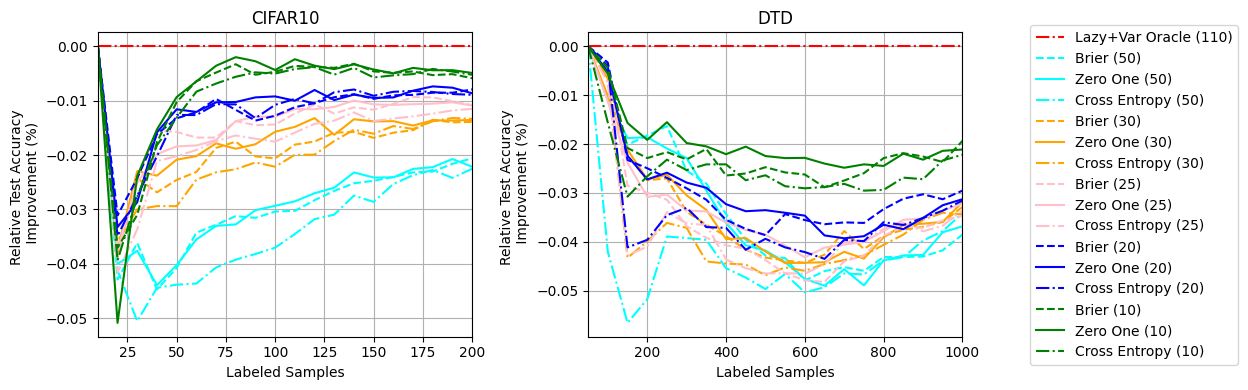

,cifar10,dtd
lazy+vary oracle(110),95.25+/-0.17,78.41+/-0.56
lazy+vary oracle(110) brier 50,-1.99+/-0.59,-3.73+/-0.52
lazy+vary oracle(110) zero_one 50,-2.08+/-0.42,-3.76+/-0.57
lazy+vary oracle(110) cross_entropy 50,-2.15+/-0.52,-3.24+/-0.51
lazy+vary oracle(110) brier 30,-1.22+/-0.35,-3.54+/-0.24
lazy+vary oracle(110) zero_one 30,-1.19+/-0.25,-3.12+/-0.68
lazy+vary oracle(110) cross_entropy 30,-1.27+/-0.15,-3.13+/-0.48
lazy+vary oracle(110) brier 25,-0.97+/-0.22,-3.25+/-0.58
lazy+vary oracle(110) zero_one 25,-1.01+/-0.17,-3.13+/-0.46
lazy+vary oracle(110) cross_entropy 25,-1.09+/-0.25,-3.03+/-0.58


,cifar10,dtd
lazy+vary oracle(110),0.91+/-0.01,0.72+/-0.0
lazy+vary oracle(110) brier 50,-0.03+/-0.01,-0.03+/-0.0
lazy+vary oracle(110) zero_one 50,-0.03+/-0.01,-0.03+/-0.0
lazy+vary oracle(110) cross_entropy 50,-0.03+/-0.01,-0.04+/-0.01
lazy+vary oracle(110) brier 30,-0.02+/-0.01,-0.03+/-0.0
lazy+vary oracle(110) zero_one 30,-0.02+/-0.01,-0.03+/-0.01
lazy+vary oracle(110) cross_entropy 30,-0.02+/-0.01,-0.04+/-0.0
lazy+vary oracle(110) brier 25,-0.01+/-0.01,-0.04+/-0.0
lazy+vary oracle(110) zero_one 25,-0.01+/-0.01,-0.03+/-0.0
lazy+vary oracle(110) cross_entropy 25,-0.02+/-0.01,-0.04+/-0.01


In [16]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}

for i, dset in enumerate(['cifar10', 'dtd']):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['lazy+vary oracle(110)'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['lazy+vary oracle(110)'] = str(rand_auc_mean.round(2)) + '+/-' + str(rand_auc_std.round(2))
    final_acc_rel[dset]['lazy+vary oracle(110)'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if 'cross_entropy ' in qs or 'zero_one ' in qs or 'brier ' in qs or qs == 'lazy+vary oracle(110)':
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'lazy+vary oracle(110)':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(2)) + '+/-' + str(aucs_std.round(2))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))
            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.25, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == 'lazy+vary oracle(110)'], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == 'lazy+vary oracle(110)'], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

In [37]:
# TODO: Time Improvement Comparison
qts = {}

for dset in ['cifar10', 'dtd']:
    qts[dset] = {}
    for strat in ['lazy+vary oracle(110)', 'lazy+vary oracle(110) zero_one 10']:
        qts[dset][strat] = {}
        times = np.mean(query_times[dset][strat], axis=0).round(2)
        for cycle in range(20):
            qts[dset][strat]['Cycle '+str(cycle)] = times[cycle]

flat_dict = {}
for group, subdict in qts.items():
    for sub, rows in subdict.items():
        for row, value in rows.items():
            flat_dict.setdefault(row, {})[(group, sub)] = value

# Step 2: Create the DataFrame
df = pd.DataFrame.from_dict(flat_dict, orient='index')

# Step 3: Sort columns if needed
df = df.sort_index(axis=1)

df

cifar10                                    \
         lazy+vary oracle(110) lazy+vary oracle(110) zero_one 10   
Cycle 0                   0.00                              0.00   
Cycle 1                  61.55                             52.85   
Cycle 2                  62.81                             53.29   
Cycle 3                  58.69                             51.50   
Cycle 4                  59.26                             50.18   
Cycle 5                  58.99                             54.68   
Cycle 6                  61.46                             53.00   
Cycle 7                  58.03                             52.06   
Cycle 8                  59.27                             48.90   
Cycle 9                  61.47                             48.92   
Cycle 10                 59.24                             50.53   
Cycle 11                 61.53                             51.48   
Cycle 12                 70.55                             52.01   
Cycle 13                 71.66                             49.49   
Cycle 14                 70.79                             51.11   
Cycle 15                 71.53                             50.24   
Cycle 16                 69.60                             51.95   
Cycle 17                 70.94                             52.83   
Cycle 18                 71.09                             50.87   
Cycle 19                 81.56                             49.58   

                           dtd                                    
         lazy+vary oracle(110) lazy+vary oracle(110) zero_one 10  
Cycle 0                   0.00                              0.00  
Cycle 1                  65.43                             58.80  
Cycle 2                  67.35                             54.32  
Cycle 3                  73.81                             57.49  
Cycle 4                  75.64                             50.74  
Cycle 5                  81.87                             47.63  
Cycle 6                  94.67                             46.92  
Cycle 7                 101.48                             44.84  
Cycle 8                 112.94                             47.11  
Cycle 9                 113.36                             45.70  
Cycle 10                120.98                             47.29  
Cycle 11                132.28                             43.27  
Cycle 12                142.57                             42.51  
Cycle 13                138.87                             45.17  
Cycle 14                145.14                             44.53  
Cycle 15                151.99                             41.36  
Cycle 16                162.04                             50.65  
Cycle 17                172.24                             39.14  
Cycle 18                168.88                             42.53  
Cycle 19                178.27                             39.89

# Experiment 6 - Final Oracle Model on all Image-Datasets

The final oracle-model is build as follows:

Number of Batches: 110

Selection Strategies: All except Margin and BADGE

Performance Estimation: Brier-Score

In [38]:
experiment_name = 'experiment_7'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    key = 'Oracle'
    dataset = run.data.params['dataset_name']
    backbone = run.data.params['backbone']
    if backbone == 'dinov2':
        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']:
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = defaultdict(list)
            all_acc_curves_strategies[dataset][key].append(accs)
            if dataset not in query_times:
                query_times[dataset] = defaultdict(list)
            query_times[dataset][key].append(qts)
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = defaultdict(list)
            all_pick_choices[dataset][key].append(pick_choices)
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_7 #####################################
Found 150 experiments for experiment_7 with expected 90 experiments.


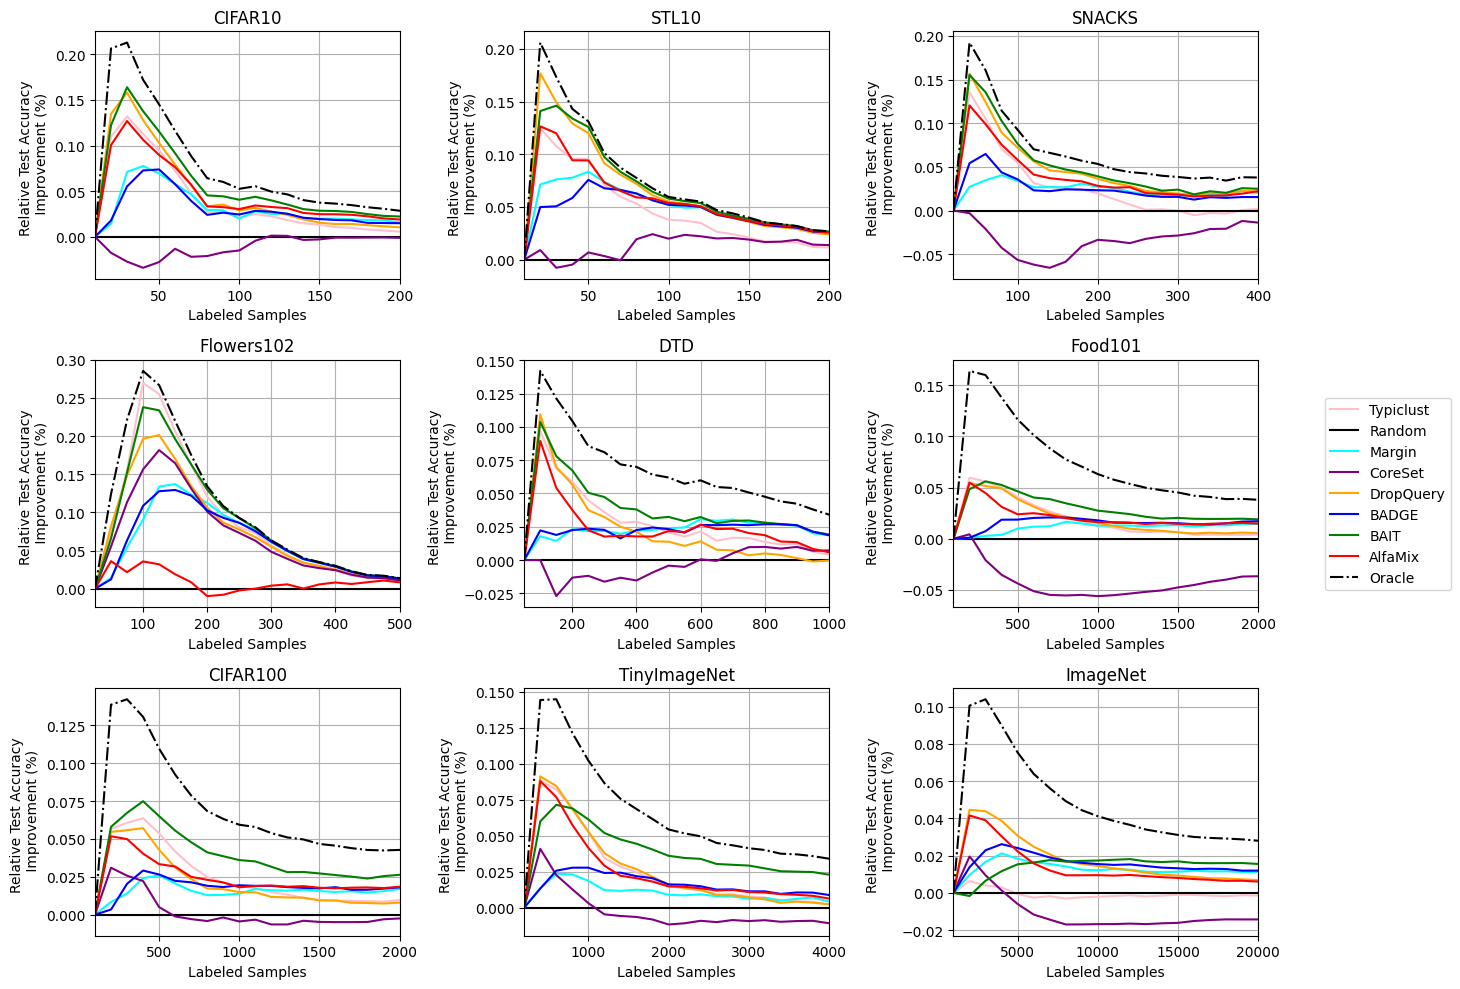

,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet
random,92.46+/-0.76,96.43+/-0.84,89.81+/-0.89,98.19+/-0.73,75.02+/-0.54,77.65+/-0.31,76.48+/-0.37,72.94+/-0.26,70.37+/-0.14
typiclust,0.55+/-0.3,1.06+/-0.29,-0.39+/-0.75,0.84+/-0.18,0.22+/-0.8,0.36+/-0.3,0.79+/-0.32,0.19+/-0.39,-0.11+/-0.18
margin,1.65+/-0.2,2.5+/-0.1,1.52+/-0.38,1.11+/-0.11,1.61+/-0.77,1.49+/-0.46,1.65+/-0.4,0.47+/-0.32,1.18+/-0.12
dropquery,1.06+/-0.33,2.26+/-0.09,1.92+/-0.6,0.98+/-0.14,-0.18+/-0.42,0.46+/-0.33,0.79+/-0.26,0.16+/-0.2,0.67+/-0.23
coreset,0.12+/-0.5,1.39+/-0.32,-1.26+/-0.79,0.9+/-0.11,0.46+/-0.59,-3.64+/-0.64,-0.31+/-0.55,-0.9+/-0.23,-1.31+/-0.2
bait,2.22+/-0.18,2.54+/-0.08,2.04+/-0.38,1.11+/-0.1,1.75+/-0.51,1.78+/-0.26,2.54+/-0.34,2.21+/-0.37,1.55+/-0.13
badge,1.45+/-0.27,2.48+/-0.1,1.39+/-0.61,1.1+/-0.08,1.63+/-0.51,1.61+/-0.43,1.74+/-0.27,0.94+/-0.25,1.26+/-0.16
alfamix,1.88+/-0.37,2.46+/-0.07,1.7+/-0.59,0.67+/-0.17,0.34+/-0.72,1.45+/-0.28,1.89+/-0.39,0.62+/-0.32,0.63+/-0.2
Oracle,2.79+/-0.2,2.56+/-0.09,3.22+/-0.39,1.14+/-0.1,3.21+/-0.46,3.64+/-0.23,4.23+/-0.33,3.42+/-0.31,2.79+/-0.12


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet
random,0.833+/-0.016,0.882+/-0.011,0.827+/-0.01,0.812+/-0.014,0.658+/-0.007,0.675+/-0.005,0.667+/-0.005,0.63+/-0.003,0.619+/-0.002
typiclust,0.037+/-0.006,0.044+/-0.005,0.024+/-0.008,0.083+/-0.006,0.026+/-0.004,0.018+/-0.005,0.024+/-0.004,0.023+/-0.004,-0.001+/-0.002
margin,0.031+/-0.011,0.048+/-0.003,0.023+/-0.008,0.058+/-0.008,0.022+/-0.005,0.011+/-0.007,0.015+/-0.004,0.01+/-0.002,0.013+/-0.002
dropquery,0.045+/-0.006,0.063+/-0.004,0.043+/-0.005,0.073+/-0.004,0.02+/-0.004,0.018+/-0.003,0.02+/-0.002,0.024+/-0.002,0.017+/-0.002
coreset,-0.01+/-0.017,0.013+/-0.011,-0.031+/-0.016,0.065+/-0.008,-0.003+/-0.005,-0.041+/-0.007,0.001+/-0.005,-0.003+/-0.004,-0.01+/-0.002
bait,0.055+/-0.009,0.064+/-0.003,0.047+/-0.006,0.084+/-0.005,0.037+/-0.006,0.029+/-0.005,0.037+/-0.003,0.037+/-0.003,0.014+/-0.001
badge,0.029+/-0.008,0.044+/-0.006,0.023+/-0.005,0.058+/-0.01,0.022+/-0.008,0.015+/-0.006,0.018+/-0.004,0.016+/-0.002,0.015+/-0.002
alfamix,0.044+/-0.013,0.054+/-0.015,0.036+/-0.006,0.009+/-0.019,0.023+/-0.006,0.02+/-0.005,0.024+/-0.002,0.023+/-0.004,0.013+/-0.002
Oracle,0.073+/-0.007,0.07+/-0.003,0.062+/-0.005,0.096+/-0.005,0.063+/-0.006,0.07+/-0.003,0.067+/-0.003,0.062+/-0.002,0.046+/-0.001


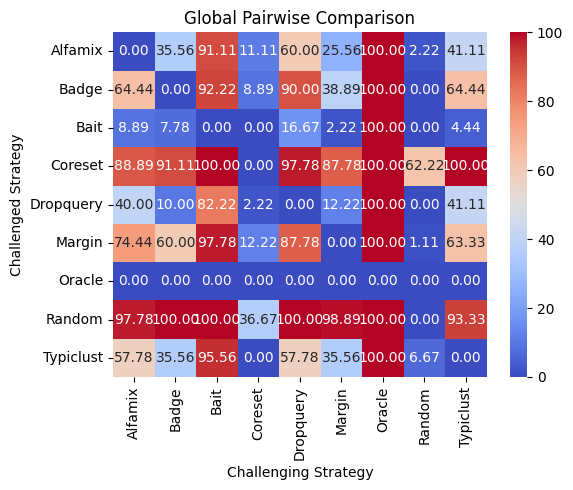

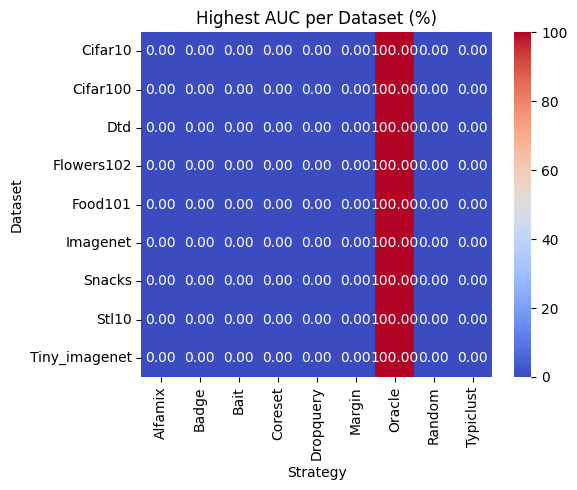

In [39]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(13, 10), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust', 'Oracle']

for i, dset in enumerate(datasets):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['random'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['random'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
    final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i//3][i%3])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if qs in strategies:
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'random':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)
plot_global_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)

## Experiment 7: Baselines+Oracle with a new Backbone (SwinV2) on all Image Datasets
Accidentally, i also saved this final oracle under the same experiment number (experiment_7). I therefore need to make a case differentiation between the backbones for future evaluations for both backbones!!!

In [ ]:
all_acc_curves_strategies_2 = {}
all_pick_choices_2 = {}
query_times_2 = {}

In [ ]:
experiment_name = 'experiment_8'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies_2:
            all_acc_curves_strategies_2[dataset] = defaultdict(list)
        all_acc_curves_strategies_2[dataset][key].append(accs)
        if dataset not in query_times_2:
            query_times_2[dataset] = defaultdict(list)
        query_times_2[dataset][key].append(qts)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

# TODO: Fix Black-White Error for AutoImageProcessor!

In [ ]:
experiment_name = 'experiment_7'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    key = 'Oracle'
    dataset = run.data.params['dataset_name']
    backbone = run.data.params['backbone']
    if backbone == 'swinv2':
        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']:
            if dataset not in all_acc_curves_strategies_2:
                all_acc_curves_strategies_2[dataset] = defaultdict(list)
            all_acc_curves_strategies_2[dataset][key].append(accs)
            if dataset not in query_times_2:
                query_times_2[dataset] = defaultdict(list)
            query_times_2[dataset][key].append(qts)
            if dataset not in all_pick_choices_2:
                all_pick_choices_2[dataset] = defaultdict(list)
            all_pick_choices_2[dataset][key].append(pick_choices)
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(13, 10), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}

for i, dset in enumerate(datasets):
    if dset != 'tiny_imagenet':
        auc_values_rel[dset] = {}
        final_acc_rel[dset] = {}

        rand_accs = all_acc_curves_strategies_2[dset]['random'] 
        avg_rand_accs = np.mean(rand_accs, axis=0)
        rand_auc = np.mean(rand_accs, axis=1)
        rand_final_accs = [ac[-1]*100 for ac in rand_accs]
        rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
        rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
        auc_values_rel[dset]['random'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
        final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

        plt.axes(ax[i//3][i%3])
        n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
        for qs in all_acc_curves_strategies_2[dset]:
            if qs in ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'typiclust', 'coreset', 'Oracle']: #
                accs = all_acc_curves_strategies_2[dset][qs]
                avg_accs = np.mean(accs, axis=0)
                final_accs = [ac[-1]*100 for ac in accs]
                aucs = np.mean(accs, axis=1)
                aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
                final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

                if qs != 'random':
                    auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                    final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

                plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
        plt.xlabel('Labeled Samples')
        plt.ylabel('Relative Test Accuracy \n Improvement (%)')
        plt.grid(True)
        plt.title(datasets[dset]['n'])
        plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)
plot_global_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)